<a href="https://colab.research.google.com/github/sofimargo/Modelado-y-Simulaci-n-de-Sistemas-Mecatr-nicos/blob/main/AF7_Proyecto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AF7 Proyecto final
## 001 V1-V3
- Saul Eduardo Torres Hernández 2120940
- Sofía Alejandra Martínez Gómez 1998005
- Suri Astrid Vallejo Fernández 2120638
- Edder Mauricio Lopez Ceniceros 2031095

In [7]:
#Importamos las librerías
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [8]:
# Se definen las ecuaciones correspondientes
def cap5_robot2gdl(t, x):
    # Estados: q1, q2 (posiciones), q1d, q2d (velocidades)
    q1, q2, q1d, q2d = x

    q = np.array([q1, q2])
    qp = np.array([q1d, q2d])

    # Matriz de inercia M(q)
    M = np.array([
        [3.117 + 0.2 * np.cos(q[1]), 0.108 + 0.1 * np.cos(q[1])],
        [0.108 + 0.1 * np.cos(q[1]), 0.108]
    ])

    # Matriz de fuerzas centrípetas y de coriolis C(q, qp)
    C = np.array([
        [-0.2 * np.sin(q[1]) * qp[1], -0.1 * np.sin(q[1]) * qp[1]],
        [ 0.1 * np.sin(q[1]) * qp[0],  0.0]
    ])

    # Vector de pares gravitacionales g(q)
    par_grav = np.array([
        39.3 * np.sin(q[0]) + 1.95 * np.sin(q[0] + q[1]),
        1.95 * np.sin(q[0] + q[1])
    ])

    # Vector de pares de fricción y Coulomb f_r(qp)
    fr = np.array([
        1.86 * qp[0] + 1.93 * np.sign(qp[0]),
        0.16 * qp[1] + 0.3 * np.sign(qp[1])
    ])

    # Vector de torques tau(t)
    tau = np.array([
        (1 - np.exp(-0.8 * t)) * 32.0 + 56 * np.sin(16 * t + 0.1) + 12 * np.sin(20 * t + 0.15),
        (1 - np.exp(-1.8 * t)) * 1.2  + 8 * np.sin(26 * t + 0.08) + 2 * np.sin(12 * t + 0.34)
    ])

    # Aceleraciones articulares: q2p = M^-1 * (tau - C*qp - par_grav - fr)
    q2p = np.linalg.solve(M, tau - C @ qp - par_grav - fr)

    # Retorna las derivadas de los estados: [velocidades, aceleraciones]
    return [qp[0], qp[1], q2p[0], q2p[1]]

In [9]:
#Parámetros de simulación
ti = 0
tf = 10
h = 0.0025

# Vector de tiempo como indica el libro
ts = np.arange(ti, tf + h, h)

# Condiciones iniciales [q1, q2, q1d, q2d] -> Robot en reposo
x0 = [0.0, 0.0, 0.0, 0.0]

sol = solve_ivp(
    cap5_robot2gdl,
    [ti, tf],
    x0,
    t_eval=ts,
    rtol=1e-3,
    max_step=2.5e-3
)

# Extracción de resultados
t = sol.t
x = sol.y.T


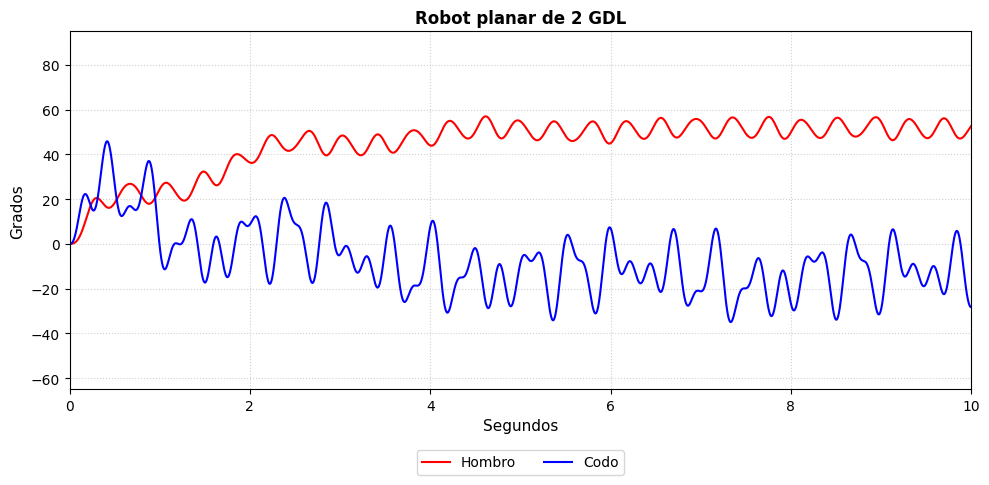

In [11]:
# Gráfica
plt.figure(figsize=(10, 5))
plt.plot(t, np.rad2deg(x[:, 0]), 'r-', label="Hombro")
plt.plot(t, np.rad2deg(x[:, 1]), 'b-', label="Codo")

plt.xlabel("Segundos", fontsize=11)
plt.ylabel("Grados", fontsize=11)
plt.title("Robot planar de 2 GDL", fontweight='bold')
plt.xlim(ti, tf)
plt.ylim(-65, 95)  # Ajustado para que coincida visualmente con la escala de la Figura 5.6 del libro
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()